## Surrogate Model for Binary Distillation Column

## 1. Setup & Configuration

In [1]:
!pip install -q xgboost


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import os
import json
import time
import warnings
import datetime
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model    import LinearRegression
from sklearn.preprocessing   import PolynomialFeatures, StandardScaler
from sklearn.multioutput     import MultiOutputRegressor
from sklearn.ensemble        import RandomForestRegressor
from sklearn.neural_network  import MLPRegressor
from sklearn.pipeline        import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics         import r2_score, mean_squared_error, mean_absolute_error

from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 30)

In [5]:
RANDOM_SEED = 42
DATA_PATH   = "data/raw/distillation.csv"
MODEL_DIR   = "models/"
FIGURE_DIR  = "figures/"
TEST_SIZE   = 0.15
VAL_SIZE    = 0.15
POLY_DEGREE = 2

np.random.seed(RANDOM_SEED)

for d in ["data/raw", MODEL_DIR, FIGURE_DIR]:
    os.makedirs(d, exist_ok=True)

## 2. Importing Dataset

* Primary Dataset: Amarhiqal (2023). Aspen Hysys Distillation Column Data from Kaggle [DataSet](https://www.kaggle.com/datasets/amarhaiqal/aspen-hysys-distillation-column-data)

* Alternate Dataset: Jorgecote (2022). Distillation Column dataset [DataSet](https://www.kaggle.com/datasets/jorgecote/distillation-column)

In [6]:
if not os.path.exists(DATA_PATH):
    os.system(
        "kaggle datasets download "
        "-d amarhaiqal/aspen-hysys-distillation-column-data "
        "--unzip -p data/raw/"
    )
    csv_files = glob.glob("data/raw/*.csv")
    if csv_files and csv_files[0] != DATA_PATH:
        os.rename(csv_files[0], DATA_PATH)

    # fallback to alternate dataset
    if not os.path.exists(DATA_PATH):
        os.system(
            "kaggle datasets download "
            "-d jorgecote/distillation-column "
            "--unzip -p data/raw/"
        )
        csv_files = glob.glob("data/raw/*.csv")
        if csv_files:
            os.rename(csv_files[0], DATA_PATH)

In [7]:
df_raw = pd.read_csv(DATA_PATH, sep=";")
print(df_raw.shape)
df_raw.head()

(4408, 21)


,Pressure,T1,T2,T3,T4,T5,T6,T7,T8,T9,T10,T11,T12,T13,T14,L,V,D,B,F,Ethanol concentration
0,1.0100,350.8900,350.9500,351.0100,351.0800,351.1600,351.2600,351.3800,351.5400,351.7800,352.1800,353.0000,355.1900,363.7700,371.4700,780,1040,260,340,600,0.8208
1,1.0100,350.8600,350.9100,350.9600,351.0200,351.0900,351.1700,351.2800,351.4300,351.6600,352.0300,352.7600,354.6600,362.2000,370.9800,780,1040,260,340,600,0.8325
2,1.0100,350.8500,350.8900,350.9300,350.9900,351.0500,351.1300,351.2300,351.3700,351.5800,351.9100,352.5500,354.1300,360.1600,370.1000,780,1040,260,340,600,0.8395
3,1.0100,350.8400,350.8800,350.9200,350.9700,351.0300,351.1100,351.2100,351.3400,351.5300,351.8300,352.4000,353.7500,358.4500,368.9900,780,1040,260,340,600,0.8437
4,1.0100,350.8300,350.8700,350.9100,350.9600,351.0200,351.0900,351.1800,351.3100,351.4900,351.7800,352.3000,353.5000,357.2300,367.8100,780,1040,260,340,600,0.8462


## 3. Exploratory Data Analysis & Data Validation

In [8]:
df_raw.info()
display(df_raw.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4408 entries, 0 to 4407
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Pressure               4408 non-null   float64
 1   T1                     4408 non-null   float64
 2   T2                     4408 non-null   float64
 3   T3                     4408 non-null   float64
 4   T4                     4408 non-null   float64
 5   T5                     4408 non-null   float64
 6   T6                     4408 non-null   float64
 7   T7                     4408 non-null   float64
 8   T8                     4408 non-null   float64
 9   T9                     4408 non-null   float64
 10  T10                    4408 non-null   float64
 11  T11                    4408 non-null   float64
 12  T12                    4408 non-null   float64
 13  T13                    4408 non-null   float64
 14  T14                    4408 non-null   float64
 15  L   

,Pressure,T1,T2,T3,T4,T5,T6,T7,T8,T9,T10,T11,T12,T13,T14,D,B,F,Ethanol concentration
count,4408.0000,4408.0000,4408.0000,4408.0000,4408.0000,4408.0000,4408.0000,4408.0000,4408.0000,4408.0000,4408.0000,4408.0000,4408.0000,4408.0000,4408.0000,4408.0000,4408.0000,4408.0000,4408.0000
mean,1.0100,351.0290,351.4094,352.0662,352.8286,353.9102,355.2143,356.4540,357.5399,358.4840,359.3013,360.0487,360.8840,364.3671,367.7173,251.8240,293.4120,545.2359,0.7922
std,0.0000,0.3341,1.1252,2.6712,3.7884,4.9865,6.2510,7.1199,7.6203,7.8822,7.9793,7.8992,7.6040,8.5630,6.6394,71.0480,108.5510,119.1928,0.0764
min,1.0100,350.7600,350.7700,350.7700,350.7900,350.8000,350.8200,350.8600,350.9100,351.0000,351.1600,351.5000,352.4300,353.1500,354.5200,150.0000,90.0000,350.0000,0.5382
5%,1.0100,350.8100,350.8300,350.8600,350.9000,350.9500,351.0100,351.0900,351.2000,351.3700,351.6200,352.0100,352.8600,353.5300,355.0800,150.0000,90.0000,350.0000,0.6083
25%,1.0100,350.8200,350.8600,350.9000,350.9500,351.0000,351.0700,351.1600,351.2800,351.4400,351.7200,352.2200,353.3200,354.7500,362.9200,150.0000,200.0000,350.0000,0.7619
50%,1.0100,350.9000,350.9900,351.1000,351.2600,351.4750,351.8400,352.3700,352.9300,353.7400,354.6000,356.7850,361.4700,370.7450,372.8100,260.0000,320.0000,600.0000,0.8175
75%,1.0100,351.0800,351.3900,351.8225,352.4100,353.7400,356.8675,361.6400,364.7500,366.8800,367.4200,367.5225,367.9100,372.4400,373.0100,260.0000,352.5000,600.0000,0.8503
95%,1.0100,351.8600,354.6215,359.7065,361.4100,367.6930,369.1000,371.4930,372.8100,372.8900,372.9865,373.0100,373.0100,373.0600,373.0700,350.0000,450.0000,650.0000,0.8590
max,1.0100,352.3200,356.0300,364.9700,368.6000,369.0600,372.5700,372.9700,373.0100,373.0100,373.0100,373.0100,373.0100,373.0600,373.0700,350.0000,450.0000,650.0000,0.8918


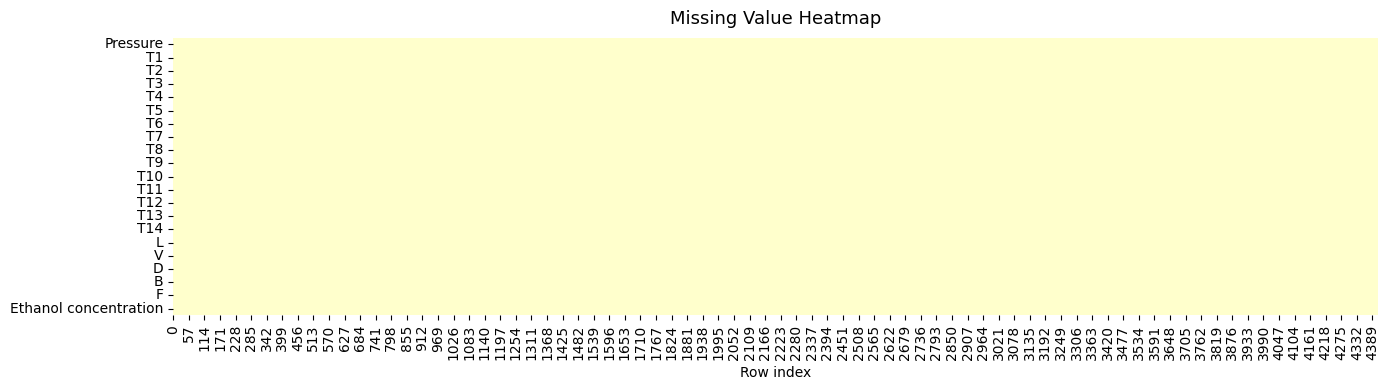

No missing values.


In [9]:
fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(df_raw.isnull().T, cbar=False, cmap="YlOrRd", yticklabels=True, ax=ax)
ax.set_title("Missing Value Heatmap", fontsize=13, pad=10)
ax.set_xlabel("Row index")
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}missing_values_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

missing = df_raw.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values.")

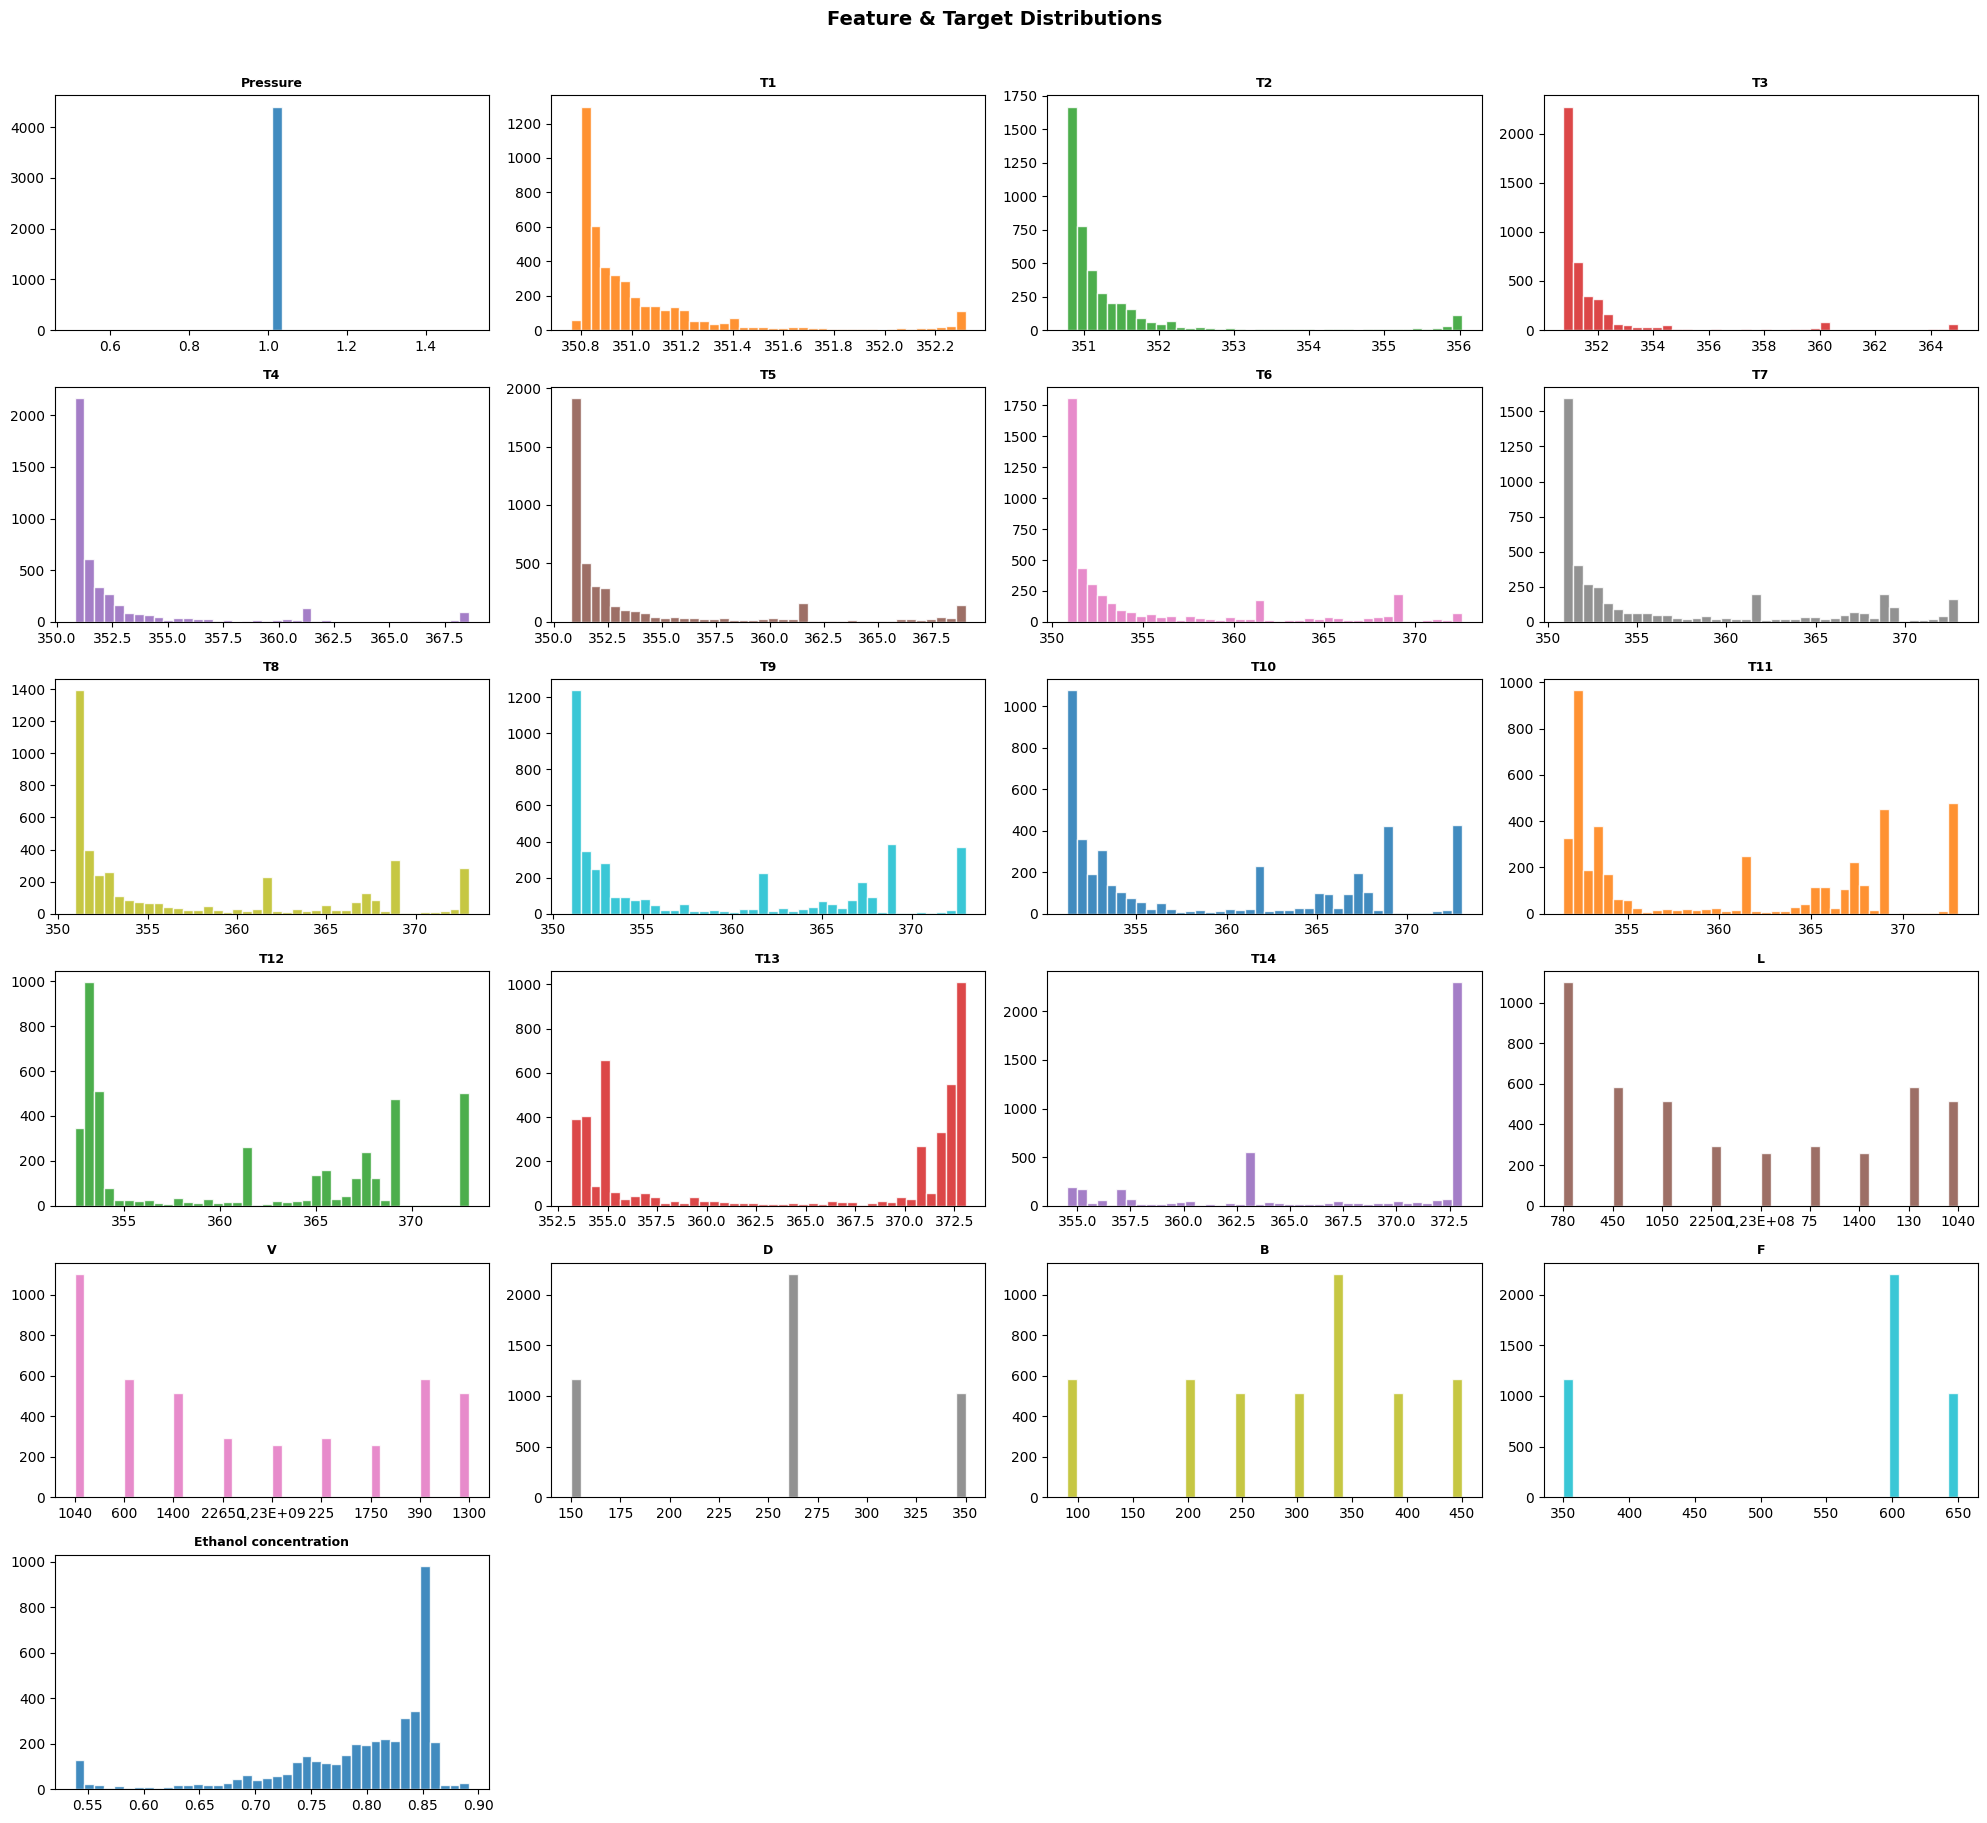

In [10]:
n_cols_data = df_raw.shape[1]
n_grid_cols = 4
n_grid_rows = (n_cols_data + n_grid_cols - 1) // n_grid_cols

fig, axes = plt.subplots(n_grid_rows, n_grid_cols,
                          figsize=(5 * n_grid_cols, 3 * n_grid_rows))
axes = axes.flatten()

palette = sns.color_palette("tab10", n_cols_data)
for i, col in enumerate(df_raw.columns):
    axes[i].hist(df_raw[col].dropna(), bins=40,
                 color=palette[i % len(palette)], edgecolor="white", alpha=0.85)
    axes[i].set_title(col, fontsize=9, fontweight="bold")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature & Target Distributions", fontsize=14, y=1.01, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}distributions.png", dpi=150, bbox_inches="tight")
plt.show()

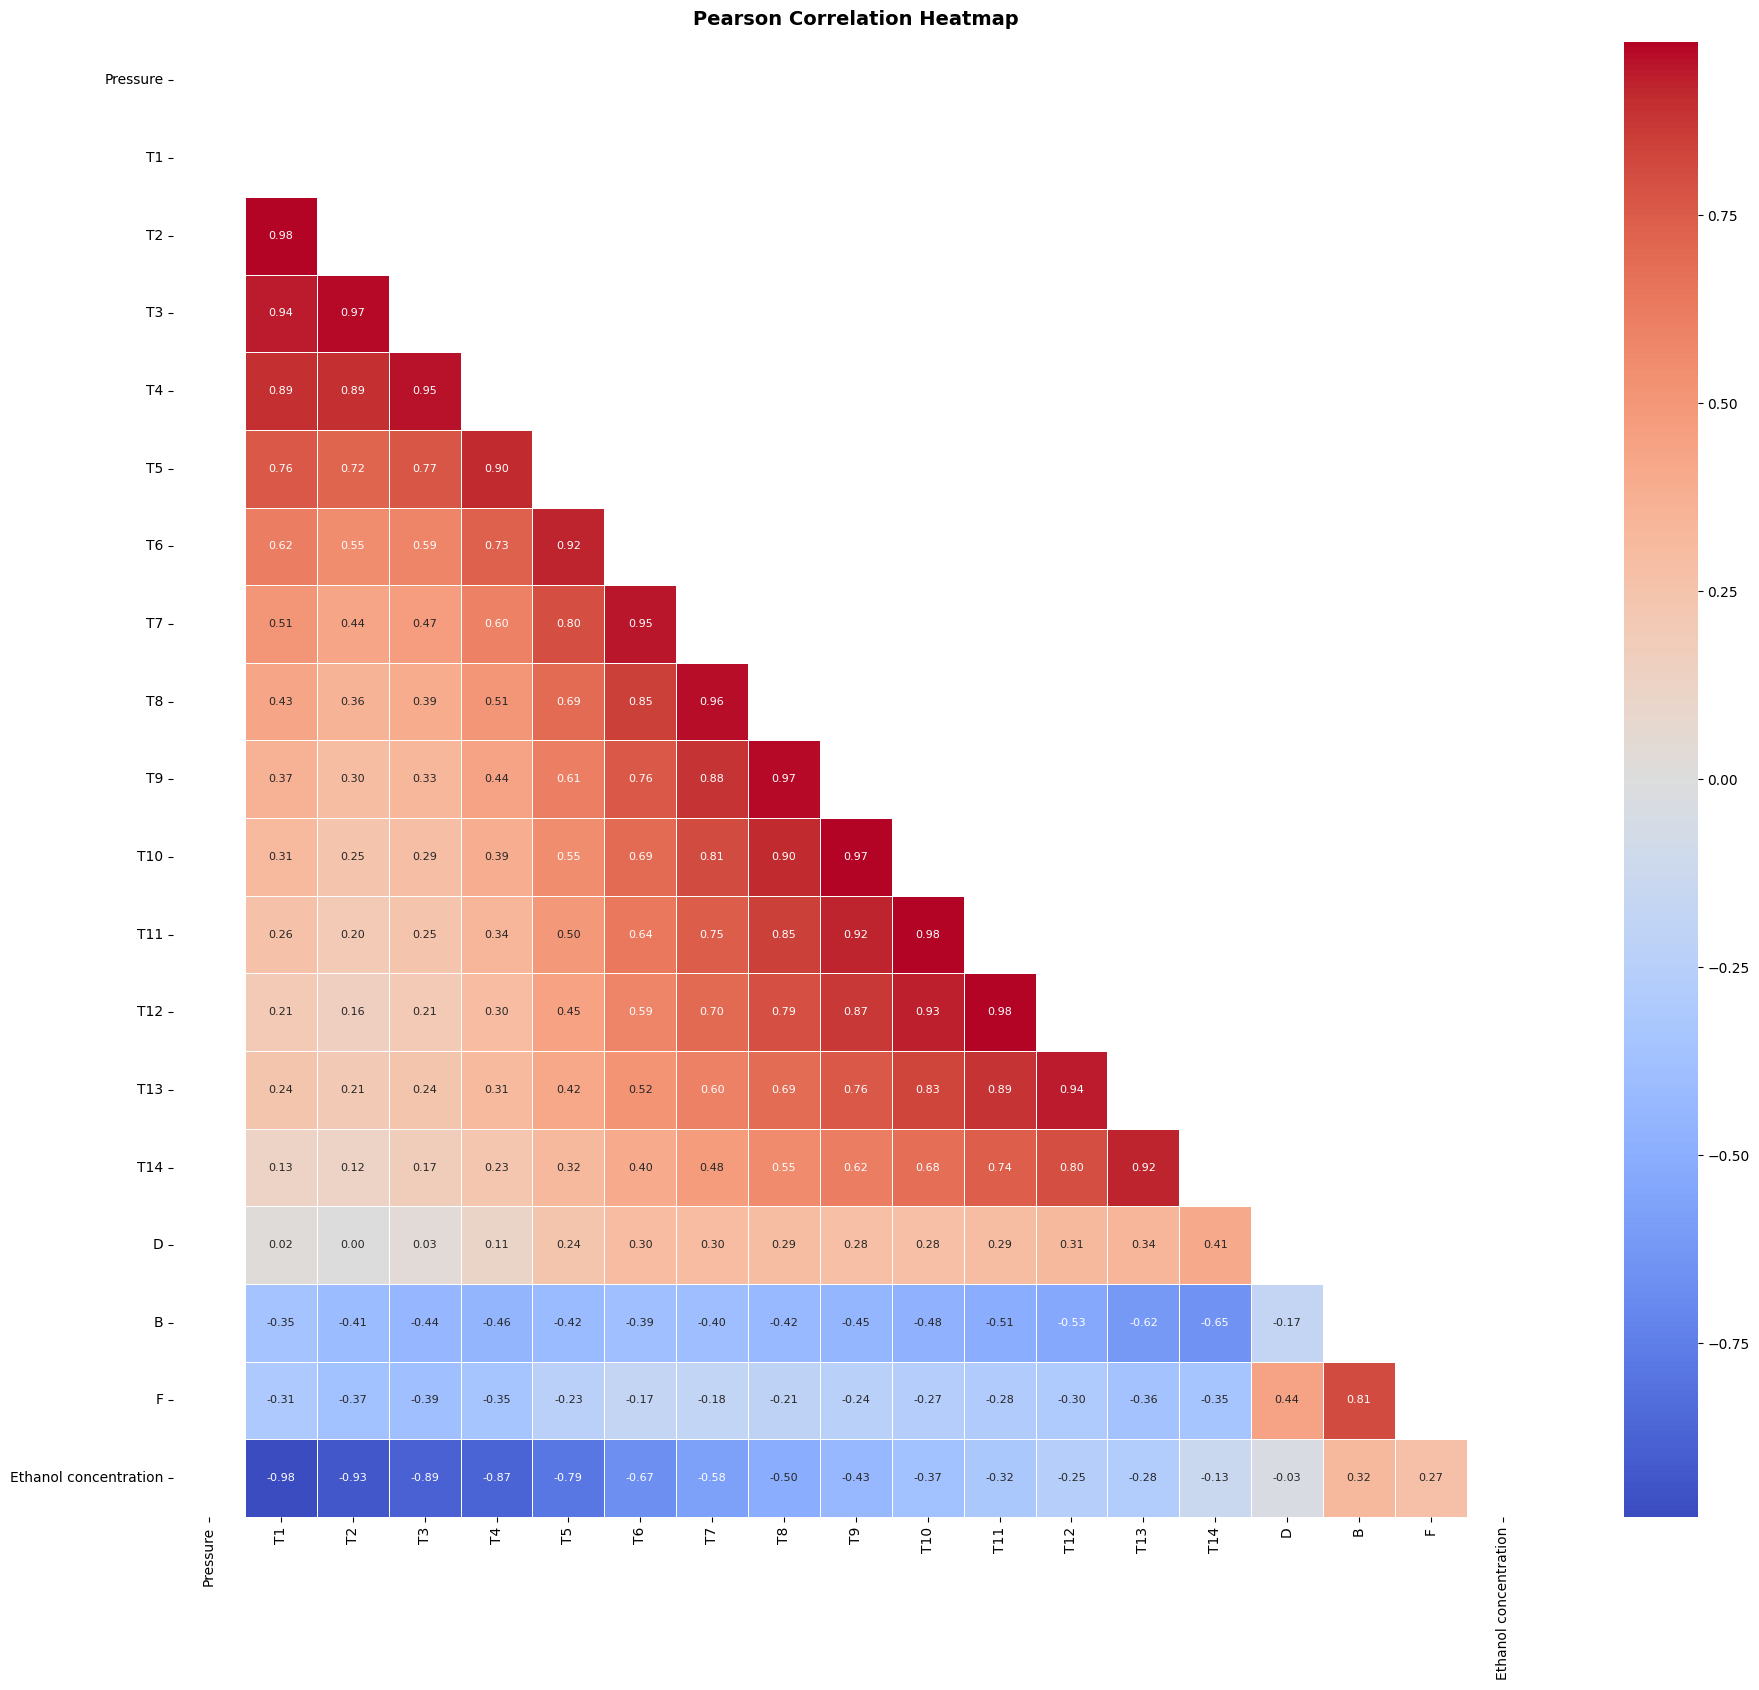

Ethanol concentration  T1    0.9810
T11                    T12   0.9805
                       T10   0.9801
T2                     T1    0.9760
T9                     T10   0.9742
T2                     T3    0.9689
T8                     T9    0.9673
                       T7    0.9596
T3                     T4    0.9500
T6                     T7    0.9459
T1                     T3    0.9394
T12                    T13   0.9352
                       T10   0.9342
Ethanol concentration  T2    0.9280
T11                    T9    0.9250
T5                     T6    0.9248
T14                    T13   0.9245
T4                     T5    0.9044
T8                     T10   0.9043
T1                     T4    0.8945


In [11]:
num_df = df_raw.select_dtypes(include=[np.number])
corr   = num_df.corr()

fig, ax = plt.subplots(figsize=(max(10, len(corr.columns)), max(8, len(corr.columns) - 2)))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, linewidths=0.5, annot_kws={"size": 8}, ax=ax
)
ax.set_title("Pearson Correlation Heatmap", fontsize=14, pad=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

high_corr = corr.abs().unstack().sort_values(ascending=False).drop_duplicates()
print(high_corr[(high_corr > 0.5) & (high_corr < 1.0)].head(20).to_string())

In [12]:
# Jorgecote dataset columns:
# Pressure, T1-T14  (tray temperatures, K)
# L (liquid flow kmol/h), V (vapour flow kmol/h)
# D (distillate rate kmol/h), B (bottoms rate kmol/h), F (feed rate kmol/h)
# Ethanol concentration  (distillate mole fraction of ethanol, 0-1)

COLUMN_MAP = {
    "Pressure":             "P_col",    # bar  (column pressure)
    "T1":                   "T1",        # K
    "T2":                   "T2",
    "T3":                   "T3",
    "T4":                   "T4",
    "T5":                   "T5",
    "T6":                   "T6",
    "T7":                   "T7",        # approximate feed-tray temperature
    "T8":                   "T8",
    "T9":                   "T9",
    "T10":                  "T10",
    "T11":                  "T11",
    "T12":                  "T12",
    "T13":                  "T13",
    "T14":                  "T14",
    "L":                    "L",         # kmol/h
    "V":                    "V",         # kmol/h
    "D":                    "D",         # kmol/h  (distillate rate)
    "B":                    "B",         # kmol/h  (bottoms rate)
    "F":                    "F",         # kmol/h  (feed rate)
    "Ethanol concentration": "x_D",     # mol/mol  (target)
}

# All tray temps + hydraulics = features; distillate purity = single target
FEATURE_COLS = ["P_col",
                "T1","T2","T3","T4","T5","T6","T7",
                "T8","T9","T10","T11","T12","T13","T14",
                "L","V","D","B","F"]
TARGET_COLS  = ["x_D"]

missing_map = [k for k in COLUMN_MAP if k not in df_raw.columns]
if missing_map:
    print(f"[WARN] COLUMN_MAP keys not in raw data: {missing_map}")
else:
    print("COLUMN_MAP OK — all keys found in df_raw.columns")
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"Targets  ({len(TARGET_COLS)}):  {TARGET_COLS}")

COLUMN_MAP OK — all keys found in df_raw.columns
Features (20): ['P_col', 'T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T10', 'T11', 'T12', 'T13', 'T14', 'L', 'V', 'D', 'B', 'F']
Targets  (1):  ['x_D']


## 3. Preprocessing & Feature Engineering

* Clean -> Drop NaN rows and invalid observation
* Split -> 70% training set / 15% validation set / 15% testing set
* Scale -> StandardScaler fitted in training data

In [14]:
df = df_raw.rename(columns=COLUMN_MAP)

# Unit Conversions
# If T_feed is in Celsius -> Kelvin:
#   df["T_feed"] = df["T_feed"] + 273.15
# If P_feed / P_col is in psi -> bar:
#   df["P_feed"] = df["P_feed"] * 0.0689476
#   df["P_col"]  = df["P_col"]  * 0.0689476
# If Q_C / Q_R is in BTU/hr -> kW:
#   df["Q_C"] = df["Q_C"] * 0.000293071
#   df["Q_R"] = df["Q_R"] * 0.000293071
# If Q_C / Q_R is in MMkcal/h -> kW:
#   df["Q_C"] = df["Q_C"] * 1162.22
#   df["Q_R"] = df["Q_R"] * 1162.22

df.head()

,P_col,T1,T2,T3,T4,T5,T6,T7,T8,T9,T10,T11,T12,T13,T14,L,V,D,B,F,x_D
0,1.0100,350.8900,350.9500,351.0100,351.0800,351.1600,351.2600,351.3800,351.5400,351.7800,352.1800,353.0000,355.1900,363.7700,371.4700,780,1040,260,340,600,0.8208
1,1.0100,350.8600,350.9100,350.9600,351.0200,351.0900,351.1700,351.2800,351.4300,351.6600,352.0300,352.7600,354.6600,362.2000,370.9800,780,1040,260,340,600,0.8325
2,1.0100,350.8500,350.8900,350.9300,350.9900,351.0500,351.1300,351.2300,351.3700,351.5800,351.9100,352.5500,354.1300,360.1600,370.1000,780,1040,260,340,600,0.8395
3,1.0100,350.8400,350.8800,350.9200,350.9700,351.0300,351.1100,351.2100,351.3400,351.5300,351.8300,352.4000,353.7500,358.4500,368.9900,780,1040,260,340,600,0.8437
4,1.0100,350.8300,350.8700,350.9100,350.9600,351.0200,351.0900,351.1800,351.3100,351.4900,351.7800,352.3000,353.5000,357.2300,367.8100,780,1040,260,340,600,0.8462


In [19]:
initial_rows = len(df)

available_feature_cols = [c for c in FEATURE_COLS if c in df.columns]
available_target_cols  = [c for c in TARGET_COLS  if c in df.columns]

if len(available_feature_cols) < len(FEATURE_COLS):
    print(f"[WARN] Missing features: {set(FEATURE_COLS) - set(available_feature_cols)}")
if len(available_target_cols) < len(TARGET_COLS):
    print(f"[WARN] Missing targets: {set(TARGET_COLS) - set(available_target_cols)}")

# ── Coerce all numeric columns to float (handles European scientific notation
# like '1,23E+08' which pandas reads as object/str when mixed with normal floats)
numeric_cols = available_feature_cols + available_target_cols
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '.', regex=False), errors='coerce')

df = df.dropna(subset=available_feature_cols + available_target_cols)

# Validate target: distillate ethanol fraction must be in (0, 1)
if "x_D" in df.columns:
    df = df[df["x_D"].between(0.0, 1.0)]

# Validate hydraulics: all flow rates must be positive
for col in ["L", "V", "D", "B", "F"]:
    if col in df.columns:
        df = df[df[col] > 0]

FEATURE_COLS = available_feature_cols
TARGET_COLS  = available_target_cols

print(f"Retained {len(df):,} / {initial_rows:,} rows ({100 * len(df) / initial_rows:.1f}%)")
assert len(df) >= 500, f"Only {len(df)} rows after cleaning -- consider the alternate dataset."

Retained 4,408 / 4,408 rows (100.0%)


In [20]:
# No engineered ratio features needed for this dataset;
# all 20 features are already in FEATURE_COLS.
FEATURE_COLS_ENG = FEATURE_COLS

df[FEATURE_COLS_ENG + TARGET_COLS].describe()

,P_col,T1,T2,T3,T4,T5,T6,T7,T8,T9,T10,T11,T12,T13,T14,L,V,D,B,F,x_D
count,4408.0000,4408.0000,4408.0000,4408.0000,4408.0000,4408.0000,4408.0000,4408.0000,4408.0000,4408.0000,4408.0000,4408.0000,4408.0000,4408.0000,4408.0000,4408.0000,4408.0000,4408.0000,4408.0000,4408.0000,4408.0000
mean,1.0100,351.0290,351.4094,352.0662,352.8286,353.9102,355.2143,356.4540,357.5399,358.4840,359.3013,360.0487,360.8840,364.3671,367.7173,7201282.5669,71994163.6332,251.8240,293.4120,545.2359,0.7922
std,0.0000,0.3341,1.1252,2.6712,3.7884,4.9865,6.2510,7.1199,7.6203,7.8822,7.9793,7.8992,7.6040,8.5630,6.6394,28876119.4211,288765842.8027,71.0480,108.5510,119.1928,0.0764
min,1.0100,350.7600,350.7700,350.7700,350.7900,350.8000,350.8200,350.8600,350.9100,351.0000,351.1600,351.5000,352.4300,353.1500,354.5200,75.0000,225.0000,150.0000,90.0000,350.0000,0.5382
25%,1.0100,350.8200,350.8600,350.9000,350.9500,351.0000,351.0700,351.1600,351.2800,351.4400,351.7200,352.2200,353.3200,354.7500,362.9200,450.0000,600.0000,150.0000,200.0000,350.0000,0.7619
50%,1.0100,350.9000,350.9900,351.1000,351.2600,351.4750,351.8400,352.3700,352.9300,353.7400,354.6000,356.7850,361.4700,370.7450,372.8100,780.0000,1040.0000,260.0000,320.0000,600.0000,0.8175
75%,1.0100,351.0800,351.3900,351.8225,352.4100,353.7400,356.8675,361.6400,364.7500,366.8800,367.4200,367.5225,367.9100,372.4400,373.0100,1050.0000,1400.0000,260.0000,352.5000,600.0000,0.8503
max,1.0100,352.3200,356.0300,364.9700,368.6000,369.0600,372.5700,372.9700,373.0100,373.0100,373.0100,373.0100,373.0100,373.0600,373.0700,123000000.0000,1230000000.0000,350.0000,450.0000,650.0000,0.8918


In [21]:
X = df[FEATURE_COLS_ENG].values
y = df[TARGET_COLS].values        # shape (n, 1) — single target

# No z_F column in this dataset; physical-consistency rules will use P_col bounds.
z_F_idx  = None
z_F_test = None

# 85/15 test split, then carve val out of the 85%
X_tv, X_test, y_tv, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv,
    test_size=VAL_SIZE / (1.0 - TEST_SIZE),
    random_state=RANDOM_SEED
)

n = len(df)
print(f"train {X_train.shape[0]:,}  val {X_val.shape[0]:,}  test {X_test.shape[0]:,}  (total {n:,})")

train 3,084  val 662  test 662  (total 4,408)


In [22]:
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

## 5. Model Training

Five Algorithms are trained
1. Linear Regression
2. Polynomial Regression
3. Random Forest
4. XgBoost
5. Artificial Neural Network

In [23]:
# y is shape (n, 1); ravel() gives 1-D for sklearn single-output estimators
y_train_1d = y_train.ravel()

t0 = time.perf_counter()
linreg_model = LinearRegression()
linreg_model.fit(X_train_s, y_train_1d)
linreg_time = time.perf_counter() - t0

train_r2 = r2_score(y_train_1d, linreg_model.predict(X_train_s))
print(f"linreg  {linreg_time:.2f}s  train R2={train_r2:.4f}")

linreg  0.02s  train R2=0.9904


In [24]:
t0 = time.perf_counter()
polyreg_model = Pipeline([
    ("poly",   PolynomialFeatures(degree=POLY_DEGREE, include_bias=False)),
    ("linreg", LinearRegression())
])
polyreg_model.fit(X_train_s, y_train_1d)
polyreg_time = time.perf_counter() - t0

n_poly_feats = polyreg_model.named_steps["poly"].n_output_features_
train_r2 = r2_score(y_train_1d, polyreg_model.predict(X_train_s))
print(f"polyreg  {polyreg_time:.2f}s  poly_feats={n_poly_feats}  train R2={train_r2:.4f}")

polyreg  0.25s  poly_feats=230  train R2=0.9998


In [25]:
rf_param_dist = {
    "n_estimators":      [100, 200, 300, 400, 500],
    "max_depth":         [None, 10, 15, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "max_features":      ["sqrt", "log2", 0.5, 0.7],
    "bootstrap":         [True, False],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=30,
    cv=5,
    scoring="r2",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

t0 = time.perf_counter()
rf_search.fit(X_train_s, y_train_1d)
rf_time  = time.perf_counter() - t0
rf_model = rf_search.best_estimator_

print(f"rf  {rf_time:.1f}s  best CV R2={rf_search.best_score_:.4f}")
print(rf_search.best_params_)

rf  42.7s  best CV R2=0.9999
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.7, 'max_depth': 15, 'bootstrap': True}


In [26]:
xgb_param_dist = {
    "n_estimators":     [100, 200, 300, 500],
    "max_depth":        [3, 4, 5, 6, 7, 9],
    "learning_rate":    [0.01, 0.05, 0.1, 0.15, 0.2],
    "subsample":        [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma":            [0, 0.1, 0.2, 0.3],
    "reg_alpha":        [0, 0.01, 0.1],
    "reg_lambda":       [1, 1.5, 2],
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=RANDOM_SEED, verbosity=0),
    param_distributions=xgb_param_dist,
    n_iter=30,
    cv=5,
    scoring="r2",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

t0 = time.perf_counter()
xgb_search.fit(X_train_s, y_train_1d)
xgb_time  = time.perf_counter() - t0
xgb_model = xgb_search.best_estimator_

print(f"xgb  {xgb_time:.1f}s  best CV R2={xgb_search.best_score_:.4f}")
print(xgb_search.best_params_)

xgb  10.3s  best CV R2=0.9999
{'subsample': 0.6, 'reg_lambda': 1.5, 'reg_alpha': 0.01, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 9, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 1.0}


In [27]:
# Combine train + val so early stopping can carve its own internal val split
X_ann = np.vstack([X_train_s, X_val_s])
y_ann = np.concatenate([y_train_1d, y_val.ravel()])
ann_val_fraction = X_val_s.shape[0] / X_ann.shape[0]

ann_model = MLPRegressor(
    hidden_layer_sizes=(256, 128, 64),
    activation="relu",
    learning_rate="adaptive",
    learning_rate_init=1e-3,
    max_iter=500,
    early_stopping=True,
    validation_fraction=ann_val_fraction,
    n_iter_no_change=20,
    tol=1e-5,
    random_state=RANDOM_SEED,
)

t0 = time.perf_counter()
ann_model.fit(X_ann, y_ann)
ann_time = time.perf_counter() - t0

print(f"ann  {ann_time:.2f}s  stopped at iter {ann_model.n_iter_}  best_loss={ann_model.best_loss_:.6f}")

TypeError: unsupported format string passed to NoneType.__format__

In [28]:
trained_models = {
    "linreg":  linreg_model,
    "polyreg": polyreg_model,
    "rf":      rf_model,
    "xgb":     xgb_model,
    "ann":     ann_model,
}

training_times = {
    "linreg":  linreg_time,
    "polyreg": polyreg_time,
    "rf":      rf_time,
    "xgb":     xgb_time,
    "ann":     ann_time,
}

## 6. Evaluation

In [29]:
def compute_metrics(y_true, y_pred, target_names):
    metrics = {}
    for i, name in enumerate(target_names):
        yt, yp = y_true[:, i], y_pred[:, i]
        nonzero = yt != 0
        mape = float(np.mean(np.abs((yt[nonzero] - yp[nonzero]) / yt[nonzero])) * 100) \
               if nonzero.sum() > 0 else float("nan")
        metrics[name] = {
            "r2":   round(float(r2_score(yt, yp)), 6),
            "rmse": round(float(np.sqrt(mean_squared_error(yt, yp))), 6),
            "mae":  round(float(mean_absolute_error(yt, yp)), 6),
            "mape": round(mape, 4),
        }
    return metrics

In [30]:
results = {}
y_test_2d = y_test.reshape(-1, 1) if y_test.ndim == 1 else y_test

for name, model in trained_models.items():
    y_pred_1d = model.predict(X_test_s)
    y_pred    = y_pred_1d.reshape(-1, 1)
    m = compute_metrics(y_test_2d, y_pred, TARGET_COLS)
    m["training_time_s"]    = round(training_times[name], 4)
    m["physical_pass_rate"] = None
    results[name] = m

    per_r2  = [m[t]["r2"] for t in TARGET_COLS]
    mean_r2 = np.mean(per_r2)
    print(f"{name:<10}  " + "  ".join(f"{v:.4f}" for v in per_r2) + f"  mean={mean_r2:.4f}")

linreg      0.9911  mean=0.9911
polyreg     0.2152  mean=0.2152
rf          0.9999  mean=0.9999
xgb         0.9999  mean=0.9999
ann         0.9896  mean=0.9896


In [31]:
rows = []
for model_name, m in results.items():
    for target in TARGET_COLS:
        rows.append({
            "Model":  model_name,
            "Target": target,
            "R2":     m[target]["r2"],
            "RMSE":   m[target]["rmse"],
            "MAE":    m[target]["mae"],
            "MAPE_%": m[target]["mape"],
        })

metrics_df = pd.DataFrame(rows)
pivot_df   = metrics_df.pivot(index="Model", columns="Target", values=["R2", "RMSE", "MAE", "MAPE_%"])
pivot_df   = pivot_df.swaplevel(axis=1).sort_index(axis=1)

r2_subcols = [(t, "R2") for t in TARGET_COLS if t in pivot_df.columns.get_level_values(0)]
if r2_subcols:
    pivot_df[("Summary", "Mean_R2")] = pivot_df[r2_subcols].mean(axis=1)

def _color_r2(val):
    if not isinstance(val, float): return ""
    if val >= 0.92: return "background-color: #198754; color: white"
    if val >= 0.90: return "background-color: #d4edda"
    if val >= 0.80: return "background-color: #fff3cd"
    return "background-color: #f8d7da"

r2_cols_idx = [(t, "R2") for t in TARGET_COLS] + [("Summary", "Mean_R2")]
r2_cols_idx = [c for c in r2_cols_idx if c in pivot_df.columns]

display(
    pivot_df.style
            .format("{:.4f}")
            .map(_color_r2, subset=r2_cols_idx)
            .set_caption("Model Performance on Hold-out Test Set  (green >= 0.92, yellow >= 0.90, red < 0.80)")
)

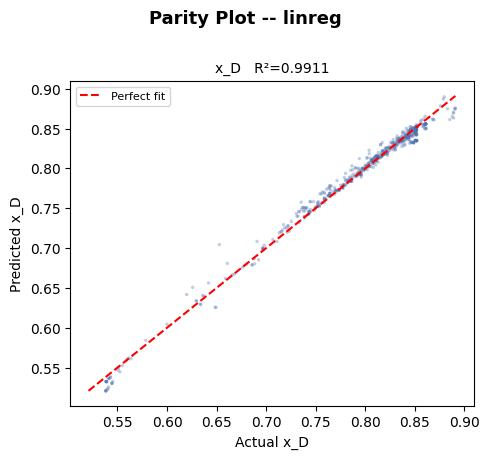

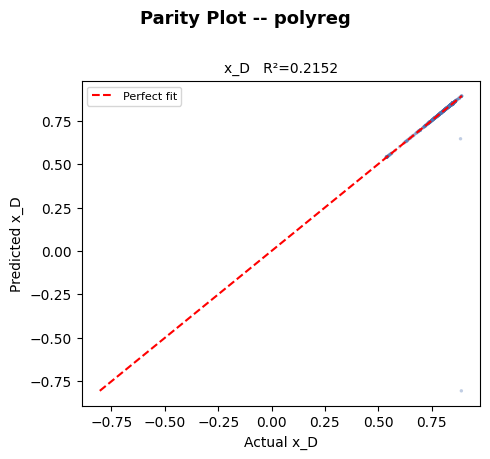

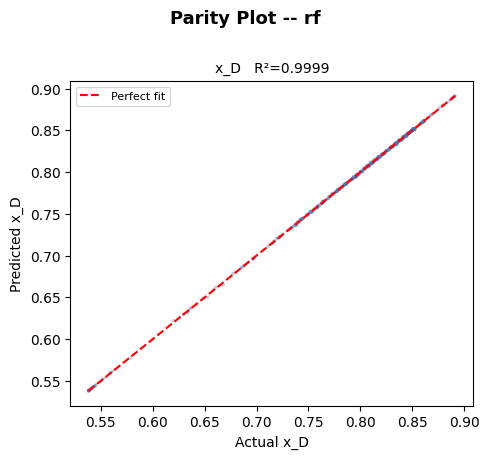

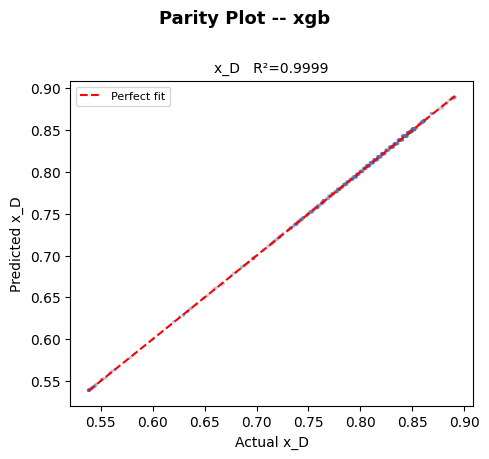

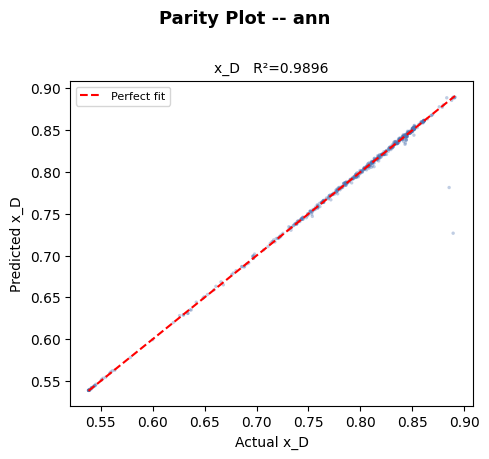

In [32]:
for model_name, model in trained_models.items():
    y_pred_1d = model.predict(X_test_s)

    fig, ax = plt.subplots(1, 1, figsize=(5, 4.5))
    fig.suptitle(f"Parity Plot -- {model_name}", fontsize=13, fontweight="bold", y=1.01)

    target = TARGET_COLS[0]
    yt, yp = y_test.ravel(), y_pred_1d.ravel()
    r2 = r2_score(yt, yp)
    lo, hi = min(yt.min(), yp.min()), max(yt.max(), yp.max())

    ax.scatter(yt, yp, s=6, alpha=0.35, color="#4C72B0", edgecolors="none")
    ax.plot([lo, hi], [lo, hi], "r--", lw=1.5, label="Perfect fit")
    ax.set_xlabel(f"Actual {target}",    fontsize=10)
    ax.set_ylabel(f"Predicted {target}", fontsize=10)
    ax.set_title(f"{target}   R²={r2:.4f}", fontsize=10)
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(f"{FIGURE_DIR}parity_{model_name}.png", dpi=150, bbox_inches="tight")
    plt.show()

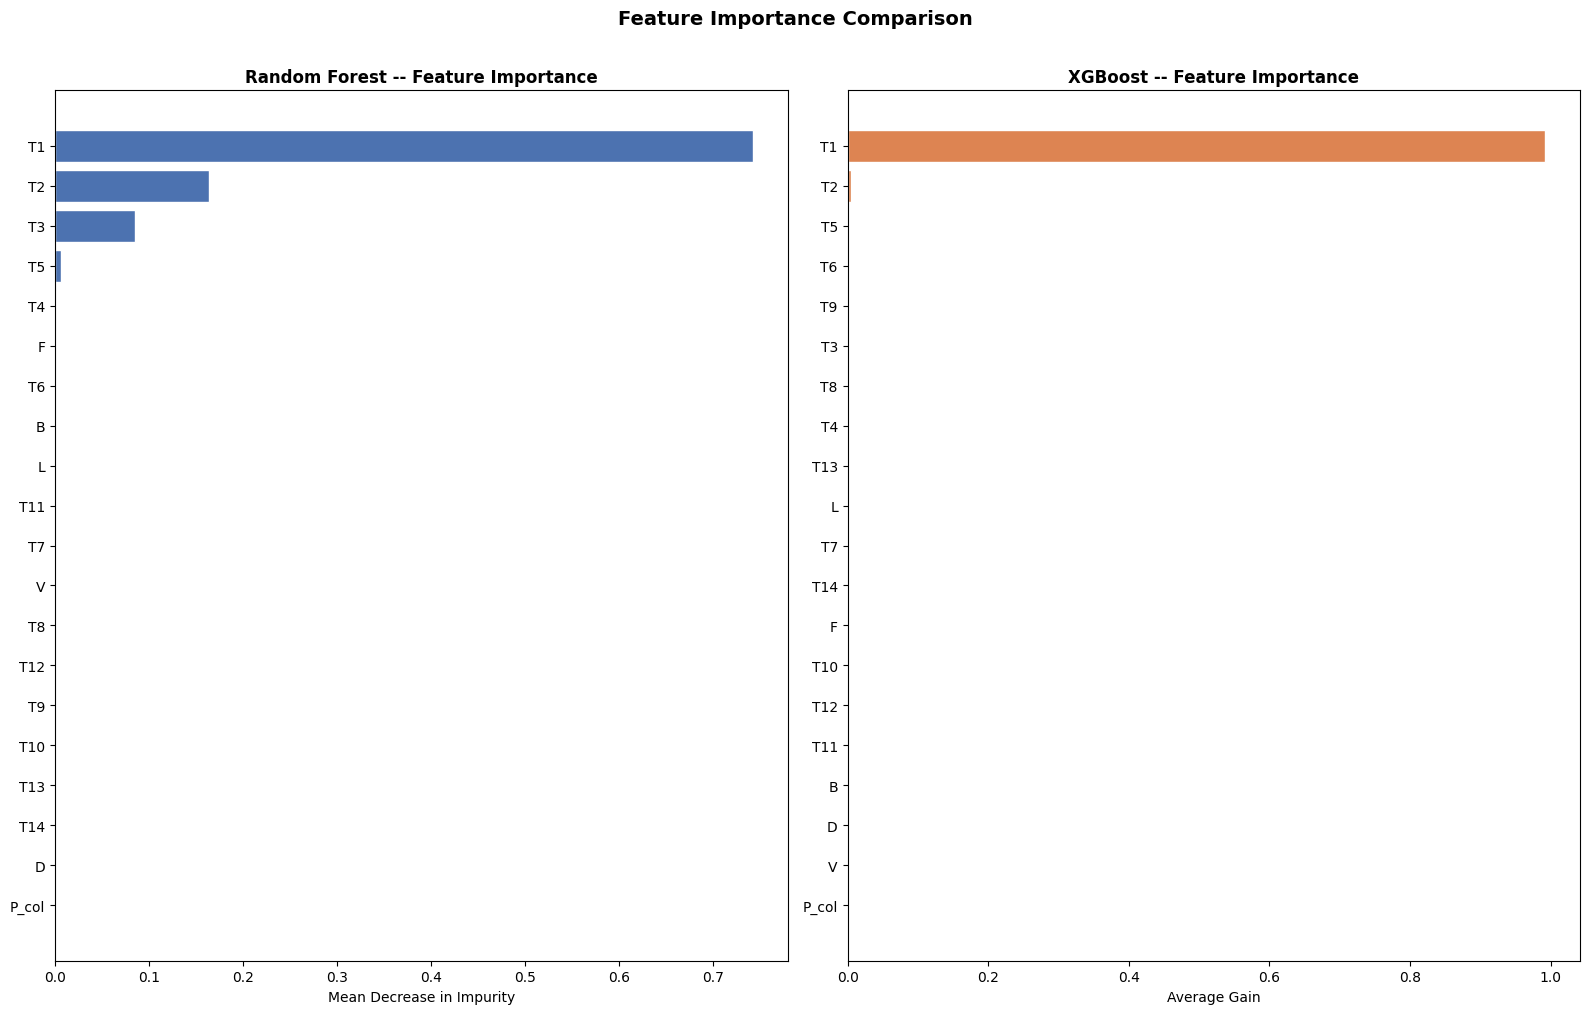

Top-3 RF:  ['T1', 'T2', 'T3']
Top-3 XGB: ['T1', 'T2', 'T5']


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, max(5, len(FEATURE_COLS_ENG) * 0.5)))

rf_imp    = rf_model.feature_importances_
rf_sorted = np.argsort(rf_imp)
axes[0].barh([FEATURE_COLS_ENG[i] for i in rf_sorted], rf_imp[rf_sorted],
             color="#4C72B0", edgecolor="white")
axes[0].set_title("Random Forest -- Feature Importance", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Mean Decrease in Impurity", fontsize=10)

# XGB is a single-output XGBRegressor — feature_importances_ directly available
xgb_imp    = xgb_model.feature_importances_
xgb_sorted = np.argsort(xgb_imp)
axes[1].barh([FEATURE_COLS_ENG[i] for i in xgb_sorted], xgb_imp[xgb_sorted],
             color="#DD8452", edgecolor="white")
axes[1].set_title("XGBoost -- Feature Importance", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Average Gain", fontsize=10)

plt.suptitle("Feature Importance Comparison", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top-3 RF: ",  [FEATURE_COLS_ENG[i] for i in rf_sorted[::-1][:3]])
print("Top-3 XGB:", [FEATURE_COLS_ENG[i] for i in xgb_sorted[::-1][:3]])

In [34]:
# Physical consistency rules for this dataset:
#   PC-01: 0 <= x_D <= 1  (distillate fraction in valid range)
#   PC-02: D > 0          (positive distillate flow)
#   PC-03: B > 0          (positive bottoms flow)
#   PC-04: F = D + B      (mass balance, within 5% tolerance)

def check_physical_consistency(y_pred_df, X_test_df=None):
    p    = y_pred_df.copy().reset_index(drop=True)
    cols = p.columns.tolist()

    rules = {}
    if "x_D" in cols:
        rules["PC-01"] = p["x_D"].between(0.0, 1.0)

    if X_test_df is not None:
        if "D" in X_test_df.columns:
            rules["PC-02"] = (X_test_df["D"].reset_index(drop=True) > 0)
        if "B" in X_test_df.columns:
            rules["PC-03"] = (X_test_df["B"].reset_index(drop=True) > 0)
        if "D" in X_test_df.columns and "B" in X_test_df.columns and "F" in X_test_df.columns:
            d = X_test_df["D"].reset_index(drop=True)
            b = X_test_df["B"].reset_index(drop=True)
            f = X_test_df["F"].reset_index(drop=True)
            rules["PC-04"] = ((d + b - f).abs() / f.replace(0, np.nan) <= 0.05)

    all_pass   = pd.Series([True] * len(p))
    rule_rates = {}
    for rule_id, mask in rules.items():
        rule_rates[rule_id] = round(float(mask.mean()), 6)
        all_pass = all_pass & mask

    return rule_rates, float(all_pass.mean())

RULE_IDS = ["PC-01", "PC-02", "PC-03", "PC-04"]

In [35]:
THRESHOLD_PHYSICAL = 0.95
physical_results   = {}

# Build a DataFrame from the test features for PC rule checking
X_test_df = pd.DataFrame(X_test, columns=FEATURE_COLS_ENG)

print(f"{'Model':<10}  " + "  ".join(f"{r:>6}" for r in RULE_IDS) + "  overall")

for name, model in trained_models.items():
    y_pred_1d  = model.predict(X_test_s)
    y_pred_df  = pd.DataFrame(y_pred_1d.reshape(-1, 1), columns=TARGET_COLS)

    rule_rates, overall = check_physical_consistency(y_pred_df, X_test_df)
    results[name]["physical_pass_rate"] = round(overall, 6)
    physical_results[name] = {"rules": rule_rates, "overall": overall}

    per_rule_str = "  ".join(f"{rule_rates.get(r, float('nan')):6.3f}" for r in RULE_IDS)
    flag = "pass" if overall >= THRESHOLD_PHYSICAL else "FAIL"
    print(f"{name:<10}  {per_rule_str}  {overall:.3f}  {flag}")

Model        PC-01   PC-02   PC-03   PC-04  overall
linreg       1.000   1.000   1.000   1.000  1.000  pass
polyreg      0.998   1.000   1.000   1.000  0.998  pass
rf           1.000   1.000   1.000   1.000  1.000  pass
xgb          1.000   1.000   1.000   1.000  1.000  pass
ann          1.000   1.000   1.000   1.000  1.000  pass


## 7. Model Selection & Conclusion

In [36]:
summary_rows = []
for model_name, m in results.items():
    row = {"Model": model_name}
    for t in TARGET_COLS:
        row[f"R2_{t}"]   = m[t]["r2"]
        row[f"MAPE_{t}"] = m[t]["mape"]
    row["Mean_R2"]      = np.mean([m[t]["r2"]   for t in TARGET_COLS])
    row["Mean_MAPE_%"]  = np.mean([m[t]["mape"] for t in TARGET_COLS])
    row["Phys_Pass_%"]  = round((m["physical_pass_rate"] or 0) * 100, 2)
    row["Train_Time_s"] = m["training_time_s"]
    summary_rows.append(row)

comparison_df = (
    pd.DataFrame(summary_rows)
      .set_index("Model")
      .sort_values("Mean_R2", ascending=False)
)

def _color_mean_r2(val):
    if not isinstance(val, (int, float)): return ""
    if val >= 0.92: return "background-color: #198754; color: white; font-weight: bold"
    if val >= 0.90: return "background-color: #d4edda"
    if val >= 0.80: return "background-color: #fff3cd"
    return "background-color: #f8d7da"

r2_col_names = [c for c in [f"R2_{t}" for t in TARGET_COLS] + ["Mean_R2"]
                if c in comparison_df.columns]

display(
    comparison_df.style
                 .format("{:.4f}", subset=r2_col_names + [f"MAPE_{t}" for t in TARGET_COLS] + ["Mean_MAPE_%"])
                 .format("{:.2f}", subset=["Phys_Pass_%", "Train_Time_s"])
                 .map(_color_mean_r2, subset=r2_col_names)
                 .set_caption("Model Ranking -- sorted by Mean R2 (descending)")
)

best_model_name = comparison_df.index[0]
best_mean_r2    = comparison_df.loc[best_model_name, "Mean_R2"]
best_phys       = comparison_df.loc[best_model_name, "Phys_Pass_%"]

print(f"\nBest: {best_model_name}  Mean R2={best_mean_r2:.4f}  Phys={best_phys:.2f}%  "
      f"MAPE={comparison_df.loc[best_model_name, 'Mean_MAPE_%']:.2f}%  "
      f"time={comparison_df.loc[best_model_name, 'Train_Time_s']:.2f}s")

,R2_x_D,MAPE_x_D,Mean_R2,Mean_MAPE_%,Phys_Pass_%,Train_Time_s
Model,,,,,,
rf,0.9999,0.0479,0.9999,0.0479,100.00,42.72
xgb,0.9999,0.0773,0.9999,0.0773,100.00,10.32
linreg,0.9911,0.6260,0.9911,0.6260,100.00,0.02
ann,0.9896,0.1762,0.9896,0.1762,100.00,9.75
polyreg,0.2152,0.4174,0.2152,0.4174,99.85,0.25



Best: rf  Mean R2=0.9999  Phys=100.00%  MAPE=0.05%  time=42.72s


In [37]:
# Override here if you prefer a different model:
# best_model_name = "rf"

best_model_path   = f"{MODEL_DIR}best_model.pkl"
metrics_json_path = f"{MODEL_DIR}metrics_summary.json"

joblib.dump(trained_models[best_model_name], best_model_path)

second_best = comparison_df.index[1] if len(comparison_df) > 1 else "-"
delta_r2    = (
    comparison_df.loc[best_model_name, "Mean_R2"] - comparison_df.loc[second_best, "Mean_R2"]
) if second_best != "-" else 0.0

metrics_summary = {
    "generated_at":       datetime.datetime.now().isoformat(timespec="seconds"),
    "random_seed":        RANDOM_SEED,
    "dataset_url":        "https://www.kaggle.com/datasets/amarhaiqal/aspen-hysys-distillation-column-data",
    "n_train":            int(X_train.shape[0]),
    "n_val":              int(X_val.shape[0]),
    "n_test":             int(X_test.shape[0]),
    "n_features":         int(X_train_s.shape[1]),
    "feature_columns":    FEATURE_COLS_ENG,
    "target_columns":     TARGET_COLS,
    "models":             results,
    "selected_model":     best_model_name,
    "selection_rationale": (
        f"{best_model_name} achieved the highest mean R2 of "
        f"{comparison_df.loc[best_model_name, 'Mean_R2']:.4f} across all "
        f"{len(TARGET_COLS)} targets on the held-out test set, outperforming "
        f"{second_best} by {delta_r2:.4f}. Physical consistency pass rate: "
        f"{comparison_df.loc[best_model_name, 'Phys_Pass_%']:.1f}%."
    )
}

with open(metrics_json_path, "w") as f:
    json.dump(metrics_summary, f, indent=2)

print(f"Best model '{best_model_name}' -> {best_model_path}")
print(f"Metrics summary  -> {metrics_json_path}")

# Success criteria
print()
for t in TARGET_COLS:
    threshold = 0.92 if t in ["x_D", "x_B"] else 0.90
    r2_val   = results[best_model_name][t]["r2"]
    mape_val = results[best_model_name][t]["mape"]
    r2_ok    = "ok" if r2_val   >= threshold else "FAIL"
    mape_ok  = "ok" if mape_val <= 5.0       else "FAIL"
    print(f"  {t}: R2={r2_val:.4f} [{r2_ok} >={threshold}]  MAPE={mape_val:.2f}% [{mape_ok} <=5%]")

    phys_ok = "ok" if comparison_df.loc[best_model_name, "Phys_Pass_%"] >= 95.0 else "FAIL"
    print(f"  Physical: {comparison_df.loc[best_model_name, 'Phys_Pass_%']:.1f}% [{phys_ok} >=95%]")

Best model 'rf' -> models/best_model.pkl
Metrics summary  -> models/metrics_summary.json

  x_D: R2=0.9999 [ok >=0.92]  MAPE=0.05% [ok <=5%]
  Physical: 100.0% [ok >=95%]
